<!-- # Fagprojekt -->

In [61]:
from pathlib import Path
import numpy as np
import vedo
from vedo import settings
from PIL import Image

from skimage.filters import threshold_otsu

import torch
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.metrics.pairwise import cosine_similarity
import math

import json

import tifffile
import time

settings.default_backend = "vtk"

In [62]:
original_path = Path("data/original_photos")
out_path = Path("data/test/final_segmented")


# label, direction, view_up
VIEWS = [
    ("+X", np.array([1, 0, 0]), np.array([0, 0, 1])),
    ("-X", np.array([-1, 0, 0]), np.array([0, 0, 1])),
    ("+Y", np.array([0, 1, 0]), np.array([0, 0, 1])),
    ("-Y", np.array([0, -1, 0]), np.array([0, 0, 1])),
    ("+Z", np.array([0, 0, 1]), np.array([0, 1, 0])),
    ("-Z", np.array([0, 0, -1]), np.array([0, 1, 0])),]

AXIS_TO_VECTOR = {
    "+X": np.array([1.0, 0.0, 0.0], dtype=float),
    "-X": np.array([-1.0, 0.0, 0.0], dtype=float),
    "+Y": np.array([0.0, 1.0, 0.0], dtype=float),
    "-Y": np.array([0.0, -1.0, 0.0], dtype=float),
    "+Z": np.array([0.0, 0.0, 1.0], dtype=float),
    "-Z": np.array([0.0, 0.0, -1.0], dtype=float),
}

animals = ["AC", "BC", "BF", "BL", "BP", "CF", "GH", "MA", "PP", "WO"]

# Small
#model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
# Base
model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Starting top3 head patch run | model={model_name} | device={device}")
print("Loading DINO processor...")
processor = AutoImageProcessor.from_pretrained(model_name)
print("Loading DINO model...")
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()
print("Model loaded.")
patch_size = int(getattr(model.config, "patch_size", 16))
num_register_tokens = int(getattr(model.config, "num_register_tokens", 0))
num_prefix_tokens = 1 + num_register_tokens  # CLS + register tokens
print(f"patch_size={patch_size} | num_register_tokens={num_register_tokens}")

zoom = 1.2
fov = 30
camera_fov = fov / zoom
patch_size = 16
grid_w = 60
grid_h = 60
image_w = grid_h * patch_size
image_h = grid_w * patch_size
render_size = (image_w, image_h)

ransac_threshold = 10
ransac_iterations = 4

# Almost white
bg_threshold = 240
# Ratio of foreground to background to include patch
fg_patch_ratio = 0.2

Starting top3 head patch run | model=facebook/dinov3-vitb16-pretrain-lvd1689m | device=cpu
Loading DINO processor...
Loading DINO model...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model loaded.
patch_size=16 | num_register_tokens=4


In [63]:
# Finds all .tif files in folders and subfolders of input
def find_input_volumes(in_root: Path) -> list[Path]:
    return sorted(in_root.rglob("*.tif"))

In [64]:
def segment_largest_component(volume: np.ndarray) -> np.ndarray:
    threshold = threshold_otsu(volume)
    mask = volume > threshold

    mask = ndimage.binary_dilation(mask,iterations=5)
    mask = ndimage.binary_fill_holes(mask)

    labeled, num = ndimage.label(mask)

    # Weighted sum of the components
    sizes = ndimage.sum_labels(volume, labeled, index=np.arange(1, num + 1))
    
    # Finds largest weight and return
    largest = int(np.argmax(sizes) + 1)
    mask = labeled == largest
    return mask

In [65]:
def render_views(
    clean_volume: np.ndarray,
    out_dir: Path,
    base_name: str,
) -> dict[str, object]:
    vol = vedo.Volume(clean_volume)
    # Locate corners
    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    p_min, p_max = np.array([xmin, ymin, zmin]), np.array([xmax, ymax, zmax])

    # Calculate camera position
    center = (p_min + p_max) / 2
    diag = np.linalg.norm(p_max - p_min)
    distance = max(diag * 1.5, 1.0)
    camera_views: list[dict[str, object]] = []

    plotter = vedo.Plotter(size=render_size, offscreen=True, bg="white")
    try:
        plotter.show(vol, resetcam=True, zoom=zoom)
        cam = plotter.camera

        for label, direction, view_up in VIEWS:
            cam.SetFocalPoint(*center)
            cam.SetPosition(*(center + direction * distance))
            cam.SetViewUp(*view_up)
            plotter.renderer.ResetCameraClippingRange()
            plotter.render()
            out_path = out_dir / f"{base_name}_{label}.png"
            plotter.screenshot(str(out_path))

            fov_y_deg = float(cam.GetViewAngle())
            cam_pos = (center + direction * distance).tolist()
            camera_views.append(
                {
                    "angle":              label,
                    "view_up":            view_up.astype(float).tolist(),
                    "camera_position":    cam_pos,
                    "camera_focal_point": center.astype(float).tolist(),
                    "fov_y_deg":          fov_y_deg,

                }
            )
    finally:
        plotter.close()

    return camera_views

In [66]:
def process_volume(in_path: Path, in_root: Path, out_root: Path) -> Path:
    # Finds the file positions
    # Finds the species from file
    rel_parent = in_path.parent.relative_to(in_root)
    # Builds ouput path
    out_dir = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    data = vedo.load(str(in_path)).tonumpy()
    mask = segment_largest_component(data)

    # Center of mass of the segmented animal (used later as the rotation center).
    # Computed here while the mask is in memory, so we don't persist the whole
    # mask volume just to recover 3 numbers downstream.
    com_xyz = [float(c) for c in ndimage.center_of_mass(mask)]

    clean_data = np.zeros_like(data)
    clean_data[mask] = data[mask]
    render_meta = render_views(clean_data, out_dir=out_dir, base_name=in_path.stem)

    # Voxel axis convention for numpy volume arrays from vedo in this project: [x, y, z].
    shape_xyz = [int(data.shape[0]), int(data.shape[1]), int(data.shape[2])]

    metadata = {
        "source_path": str(in_path),
        "output_dir": str(out_dir),
        "volume_shape": shape_xyz, 
        "kept_voxels": int(mask.sum()),
        "total_voxels": int(mask.size),
        "center_of_mass_xyz": com_xyz,
        "render_geometry": render_meta,
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return out_dir

# Finding head

In [67]:
def camera_basis(cam_pos: np.ndarray, focal: np.ndarray, view_up: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Gets right, up and front unit vectors for a camera position
    f = focal - cam_pos
    f = f / np.linalg.norm(f)
    # View up, but not orthogonal
    u0 = view_up / np.linalg.norm(view_up)
    # Right
    r = np.cross(f, u0)
    r = r / np.linalg.norm(r)
    # Orthogonal view up
    u = np.cross(r, f)
    u = u / np.linalg.norm(u)
    return r, u, f

In [68]:
def project_point_to_pixel(
    point_xyz: np.ndarray,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    image_w: int,
    image_h: int,
    fov_y_deg: float,
) -> tuple[float, float]:
    """
    Forward perspective projection: world point -> pixel (top-left origin, y down).
    Exact inverse of build_ray_from_pixel.
    Returns (px, py)
    """
    r, u, f = camera_basis(cam_pos, focal, view_up)

    w = point_xyz - cam_pos

    depth = float(np.dot(w, f))
    x_cam = float(np.dot(w, r))
    y_cam = float(np.dot(w, u))

    tan_half = math.tan(math.radians(fov_y_deg) * 0.5)

    x_ndc = (x_cam / depth) / (tan_half)
    y_ndc = (y_cam / depth) / tan_half

    nx = x_ndc * 0.5 + 0.5
    ny = 0.5 - y_ndc * 0.5

    return nx * image_w, ny * image_h

In [69]:
def get_head_information(
    in_path: Path,
    in_root: Path,
    out_root: Path,
    annotation_xyz: list[int],
) -> dict[str, dict[str, object]]:

    rel_parent = in_path.parent.relative_to(in_root)
    out_dir    = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    meta_path    = out_dir / "metadata.json"
    metadata     = json.loads(meta_path.read_text(encoding="utf-8"))
    camera_views = metadata["render_geometry"]

    world_point = annotation_xyz
    out: dict[str, dict[str, object]] = {}

    for view in camera_views:
        label   = view["angle"]
        cam_pos = np.array(view["camera_position"],    dtype=float)
        focal   = np.array(view["camera_focal_point"], dtype=float)
        view_up = np.array(view["view_up"],            dtype=float)
        fov_y   = float(view["fov_y_deg"])

        px, py = project_point_to_pixel(
            world_point, cam_pos, focal, view_up, image_w, image_h, fov_y,
        )

        col = int(px // patch_size)
        row = int(py // patch_size)

        out[label] = {
            "patch_col":      col,
            "patch_row":      row,
        }

    out_path = out_dir / "head_projection.json"
    out_path.write_text(json.dumps(out, indent=2), encoding="utf-8")
    return out

# DINOv3

In [70]:
def make_foreground_patch_mask(
    image: Image.Image,
    bg_threshold: int,
    fg_patch_ratio: float,
) -> np.ndarray:
    # Finds foreground patches

    img = np.array(image)

    # Foreground pixels
    # Check that all RGB values are under the threshold
    fg_pixel = np.all(img < bg_threshold, axis=2)

    # Reshape into patches and compute foreground fraction per patch
    patches = fg_pixel.reshape(
        grid_h, patch_size,
        grid_w, patch_size
    )

    # Average of fg_pixel over each patch
    fg_fraction = patches.mean(axis=(1, 3))

    fg_patch = fg_fraction > fg_patch_ratio

    return fg_patch.ravel()

In [71]:
def extract_patch_tokens(
    image_path: Path,
    segmented_root: Path,
    tokens_root: Path,
    processor: AutoImageProcessor,
    model: AutoModel,
    device: str,
) -> None:
    rel = image_path.relative_to(segmented_root) 
    token_dir = tokens_root / rel.parent / image_path.stem
    token_dir.mkdir(parents=True, exist_ok=True)

    tokens_path  = token_dir / "tokens.npy"

    if tokens_path.exists():
        return None

    image = Image.open(image_path).convert("RGB")

    with torch.inference_mode():
        inputs = processor(
            images=image,
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False,
        )
        pixel_values = inputs["pixel_values"].to(device)
        outputs = model(pixel_values)
        patch_tokens = outputs.last_hidden_state[:, num_prefix_tokens:, :].squeeze(0).cpu().numpy()

    np.save(tokens_path, patch_tokens)

    return None

In [72]:
def discover_segmented_individuals(segmented_root: Path, animal: str) -> list[str]:
    # Finds the segmented individuals by the subfolders of the animal
    species_dir = segmented_root / animal
    if not species_dir.exists():
        return []
    return sorted(p.name for p in species_dir.iterdir() if p.is_dir())

In [73]:
def extract_patch_tokens_animal(
    segmented_root: Path,
    tokens_root: Path,
    animal: str,
    processor: AutoImageProcessor,
    model: AutoModel,
    device: str,
) -> None:
    
    segmented_individuals = discover_segmented_individuals(segmented_root, animal)

    for individual in segmented_individuals:
        for angle, _, _ in VIEWS:
            image_path = segmented_root / animal / individual / f'{individual}_{angle}.png'
            extract_patch_tokens(
                    image_path,
                    segmented_root,
                    tokens_root,
                    processor,
                    model,
                    device,
            )
    return None

In [74]:
def build_prototype_animal(
    animal: str,
    tokens_root: Path,
    segmented_root: Path,
):
    individuals = discover_segmented_individuals(segmented_root, animal)

    proto_list = []

    for individual in individuals:
        head_info_path = segmented_root / animal / individual / "head_projection.json"
        
        if not head_info_path.exists():
            continue
        
        # Has angle:data format
        head_info = json.loads(head_info_path.read_text(encoding="utf-8"))

        for angle, angle_info in head_info.items():
            patch_row = int(angle_info["patch_row"])
            patch_col = int(angle_info["patch_col"])

            # Token files are per render image, named by scan + angle
            # e.g. data/test/tokens/AC/bcrick_1_000/bcrick_1_000_1_+X/
            tokens_path = tokens_root / animal / individual / f"{individual}_{angle}" / "tokens.npy"

            if not tokens_path.exists():
                continue

            tokens = np.load(tokens_path, mmap_mode="r")  # (n_patches, embed_dim)

            idx = patch_row * grid_w + patch_col
            token = tokens[idx].copy()
            proto_list.append(token)
    
    if not proto_list:
        raise ValueError(f"No prototype vectors could be built for animal '{animal}'")

    prototype_vector = np.mean(proto_list, axis=0)

    np.save(tokens_root / animal / "prototype_vector.npy", prototype_vector)

    return prototype_vector

# Cosine

In [75]:
def plot_patch_similarity(head_vector, tokens):
    sims = cosine_similarity([head_vector], tokens)
    sim_map = sims.reshape(grid_h,grid_w)
    plt.imshow(sim_map, cmap="jet")
    plt.colorbar()
    plt.title("Patch similarity map")
    plt.axis("off")
    plt.show()

In [76]:
def save_top_k_patches(
    tokens_root: Path,
    segmented_root: Path,
    animal: str,
    k: int,
):
    prototype_vector = np.load(tokens_root / animal / "prototype_vector.npy").reshape(1, -1)

    for individual in discover_segmented_individuals(segmented_root, animal):
        individual_dir = tokens_root / animal / individual

        for angle_dir in sorted(individual_dir.iterdir()):
            if not angle_dir.is_dir():
                continue

            tokens_path = angle_dir / "tokens.npy"
            img_path    = segmented_root / animal / individual / f"{angle_dir.name}.png"
            out_path    = angle_dir / "top_k_patches.json"

            if not tokens_path.exists() or not img_path.exists():
                continue

            tokens  = np.load(tokens_path)
            image   = Image.open(img_path).convert("RGB")
            fg_flat = make_foreground_patch_mask(image, bg_threshold, fg_patch_ratio)

            # Saves fg indicies
            fg_indices = np.where(fg_flat)[0]
            if len(fg_indices) == 0:
                continue

            fg_sims = cosine_similarity(tokens[fg_indices], prototype_vector).flatten()

            # Check if enough fg patches
            actual_k   = min(k, len(fg_indices))
            # Selects top k fg patches
            top_order  = np.argsort(fg_sims)[::-1][:actual_k]
            # Finds indices and scores
            top_flat   = fg_indices[top_order]
            top_scores = fg_sims[top_order]

            patches = []
            
            for rank, (flat_idx, score) in enumerate(zip(top_flat, top_scores)):
                row = int(flat_idx // grid_w)
                col = int(flat_idx % grid_w)
                patches.append({
                    "patch_row" : row,
                    "patch_col" : col,  
                })

            out_path.write_text(
                json.dumps({"patches": patches}, indent=2),
                encoding="utf-8",
            )

# Build rays

In [77]:
def build_ray_from_pixel(
    px: float,
    py: float,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    fov_y_deg: float,
) -> tuple[np.ndarray, np.ndarray]:
    # Normalize to [0,1]
    nx = px / float(image_w)
    ny = py / float(image_h)
    # Normalized device coordinates in [-1,1]
    x_ndc = (nx - 0.5) * 2.0
    # Image up is incresing up, y is incresing down so flip sign
    y_ndc = - ((ny - 0.5) * 2.0)
    tan_half = np.tan(np.deg2rad(fov_y_deg) * 0.5)

    d_cam = np.array([x_ndc * tan_half, y_ndc * tan_half, 1.0], dtype=float)
    d_cam = d_cam / np.linalg.norm(d_cam)

    r, u, f = camera_basis(cam_pos, focal, view_up)
    d_world = d_cam[0] * r + d_cam[1] * u + d_cam[2] * f
    d_world = d_world / np.linalg.norm(d_world)
    return cam_pos, d_world

In [78]:
def load_camera_by_angle(segmented_meta: Path) -> dict[str, dict[str, object]]:
    d = json.loads(segmented_meta.read_text(encoding="utf-8"))
    views = d.get("render_geometry", [])
    out: dict[str, dict[str, object]] = {}
    for v in views:
        angle = v.get("angle")
        out[angle] = v
    return out

In [79]:
def triangulate_rays(origins: list[np.ndarray], dirs: list[np.ndarray]) -> np.ndarray:
    A = np.zeros((3, 3), dtype=float)
    b = np.zeros(3, dtype=float)

    for o, u in zip(origins, dirs):
        M = np.eye(3) - np.outer(u, u)
        A += M
        b += M @ o

    p, *_ = np.linalg.lstsq(A, b, rcond=None)

    return p

In [80]:
def point_ray_distance(p: np.ndarray, o: np.ndarray, u: np.ndarray) -> float:
    d = p - o
    return float(np.linalg.norm(d - np.dot(u, d) * u))

In [81]:
def build_rays_from_individual(segmented_root: Path, tokens_root: Path, animal: str, individual: str):
    seg_meta = segmented_root / animal / individual / "metadata.json"
    cam_by_angle = load_camera_by_angle(seg_meta)

    origins = []
    dirs = []

    for angle, *_ in VIEWS:
        if angle not in cam_by_angle:
            continue

        cam = cam_by_angle[angle]
        cam_pos = np.array(cam["camera_position"], dtype=float)
        focal   = np.array(cam["camera_focal_point"], dtype=float)
        view_up = np.array(cam["view_up"], dtype=float)
        fov_y   = float(cam["fov_y_deg"]) 

        # Find the folder matching this specific angle
        angle_dir = tokens_root / animal / individual / f"{individual}_{angle}"
        json_path = angle_dir / "top_k_patches.json"

        if not json_path.exists():
            continue

        patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]

        for patch in patches:
            # Patch center in pixels from row/col (true center, no half-pixel offset)
            px = (patch["patch_col"] + 0.5) * patch_size
            py = (patch["patch_row"] + 0.5) * patch_size
            origin, direction = build_ray_from_pixel(
                px=px,
                py=py,
                cam_pos=cam_pos,
                focal=focal,
                view_up=view_up,
                fov_y_deg=fov_y,
            )

            origins.append(origin)
            dirs.append(direction)

    return origins, dirs

In [82]:
def ransac_fuse(
    origins: list[np.ndarray],
    dirs: list[np.ndarray],
    threshold: float,
    refine_iters: int,
) -> dict | None:
    
    def inliers_of(p: np.ndarray) -> list[int]:
        return [
            k for k in range(len(origins))
            if point_ray_distance(p, origins[k], dirs[k]) <= threshold
        ]

    best = None

    # Initial fit
    for i in range(len(origins)):
        for j in range(i + 1, len(origins)):
            if np.array_equal(origins[i], origins[j]):
                continue
            p = triangulate_rays([origins[i], origins[j]], [dirs[i], dirs[j]])

            inliers = inliers_of(p)

            if best is None or len(inliers) > best[0]:
                best = (len(inliers), p, inliers)

    if best is None:
        return None

    # Refinement
    _, p, inliers = best
    for _ in range(max(0, refine_iters)):
        if len(inliers) < 2:
            break
        p = triangulate_rays(
            [origins[k] for k in inliers],
            [dirs[k] for k in inliers],
        )
        inliers = inliers_of(p)

    return {
        "point":     p,
        "inliers":   inliers,
        "n_inliers": len(inliers),
        "threshold": threshold,
    }

In [83]:
def rotation_matrix_from_vectors(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a.astype(float)
    b = b.astype(float)
    a /= max(np.linalg.norm(a), 1e-12)
    b /= np.linalg.norm(b)

    v = np.cross(a, b)
    c = float(np.dot(a, b)) # cos between a and b
    s = float(np.linalg.norm(v)) # sin between a and b

    # Check if already parallel
    if s < 1e-12:
        # If pointing same direction
        if c > 0.0:
            return np.eye(3)
        
        # Not one fixed axis so
        # 180-degree rotation around any axis orthogonal to a.
        axis = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(axis, a)) > 0.9:
            axis = np.array([0.0, 1.0, 0.0])

        # Gram-Schmidt to make axis and a orthogonal
        axis = axis - np.dot(axis, a) * a
        axis /= max(np.linalg.norm(axis), 1e-12)
        return 2.0 * np.outer(axis, axis) - np.eye(3)

    vx = np.array(
        [
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0],
        ],
    )
    r = np.eye(3) + vx + (vx @ vx) * ((1.0 - c) / (s * s))
    return r

In [84]:
def rotate_volume(volume: np.ndarray, rot: np.ndarray, order: int, center: np.ndarray) -> np.ndarray:
    r_inv  = rot.T
    offset = center - r_inv @ center
    rotated = ndimage.affine_transform(
        volume,
        matrix=r_inv,
        offset=offset,
        order=order,
        mode="constant",
        cval=0.0,
        prefilter=order > 1,
    )
    return rotated

# Run all

In [ ]:
def run_all(original_path, info_path):
    info_path.mkdir(parents=True, exist_ok=True)

    path_anno   = Path("Annoteringer/annotations_output/image_annotations.json")
    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    volumes     = find_input_volumes(original_path)
    input_root  = original_path
    output_root = info_path / "segmented"

    # 1. Segment + render 6 views + metadata.json
    for f in volumes:
        if str(f.parts[-2]) not in animals:
            continue
        print("Processing volume:", f.name)
        process_volume(f, input_root, output_root)

    # 2. Project annotated head into each view (analytic; reads metadata.json)
    for f in volumes:
        animal_key     = str(f.parts[-2])
        individual_key = str(f.parts[-1])
        if animal_key not in animals:
            continue
        if animal_key not in annotations or individual_key not in annotations[animal_key]:
            print(f"  skipping {f.name} — not in annotations")
            continue
        annotation_xyz = annotations[animal_key][individual_key]
        get_head_information(f, input_root, output_root, annotation_xyz)

    tokens_root = info_path / "tokens"

    # 3. DINO patch tokens per view
    for animal in animals:
        extract_patch_tokens_animal(output_root,tokens_root, animal, processor, model, device)

    # 4. Head prototype per species
    for animal in animals:
        build_prototype_animal(animal, tokens_root, output_root)

    # 5. Top-k head patches per view   (needs output_root to recompute fg from PNG)
    for animal in animals:
        save_top_k_patches(tokens_root, output_root, animal, k=4)

    # 6. Triangulate head, rotate head -> +Y, re-segment for QA
    for animal in animals:
        for individual in discover_segmented_individuals(output_root, animal):
            origins, dirs = build_rays_from_individual(output_root, tokens_root, animal, individual)
            if len(origins) < 2:
                print(f"  [{animal} {individual}] skipping — not enough rays")
                continue

            result_ransac = ransac_fuse(
                origins, dirs, threshold=ransac_threshold, refine_iters=ransac_iterations,
            )
            if result_ransac is None:
                print(f"  [{animal} {individual}] skipping — RANSAC failed")
                continue

            head_xyz = result_ransac["point"]

            meta    = json.loads((output_root / animal / individual / "metadata.json").read_text(encoding="utf-8"))
            com_xyz = np.array(meta["center_of_mass_xyz"], dtype=float)
            v_xyz   = head_xyz - com_xyz

            in_path = original_path / animal / f"{individual}.tif"
            volume  = vedo.load(str(in_path)).tonumpy()

            target_axis = AXIS_TO_VECTOR['+Y']                      
            rot     = rotation_matrix_from_vectors(v_xyz, target_axis)
            rotated = rotate_volume(volume, rot=rot, order=1, center=com_xyz)  

            out_tif_dir = info_path / "final" / animal
            out_tif_dir.mkdir(parents=True, exist_ok=True)
            out_tif = out_tif_dir / f"{individual}.tif"
            tifffile.imwrite(str(out_tif), rotated.astype(volume.dtype, copy=False))
            print(f"Saved {out_tif}")

            process_volume(out_tif, info_path / "final", info_path / "final_segmented")
            print(f"Processed {individual}")

In [87]:
original_path = Path("data/original_photos")
info_path = Path("data/test_dinov3_test_base_model")

run_all(original_path, info_path)

KeyboardInterrupt: 

# Six-views

In [88]:
def plot_six_views(
    root: Path,
    animal: str,
    individual: str,
    save_path: Path | None = None,
):
    import matplotlib.pyplot as plt
    from PIL import Image

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for ax, (angle, *_) in zip(axes, VIEWS):
        img_path = root / animal / individual / f"{individual}_{angle}.png"

        if not img_path.exists():
            ax.set_title(f"{angle} — missing")
            ax.axis("off")
            continue

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(angle, fontsize=12)
        ax.axis("off")

    plt.suptitle(f"{animal} / {individual}", fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        save_path.mkdir(parents=True, exist_ok=True)
        out = save_path / f"{animal}_{individual}_six_views.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  saved six-view image: {out}")

    plt.show()

In [89]:
def plot_all_six_views(final_segmented_root: Path):
    from PIL import Image
    import matplotlib
    matplotlib.use("Agg")  # non-interactive backend
    import matplotlib.pyplot as plt

    for animal_dir in sorted(final_segmented_root.iterdir()):
        if not animal_dir.is_dir():
            continue
        animal = animal_dir.name

        for individual_dir in sorted(animal_dir.iterdir()):
            if not individual_dir.is_dir():
                continue
            individual = individual_dir.name

            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.ravel()

            for ax, (angle, *_) in zip(axes, VIEWS):
                img_path = individual_dir / f"{individual}_{angle}.png"

                if not img_path.exists():
                    ax.set_title(f"{angle} — missing")
                    ax.axis("off")
                    continue

                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(angle, fontsize=12)
                ax.axis("off")

            plt.suptitle(f"{animal} / {individual}", fontsize=14)
            plt.tight_layout()

            out_path = individual_dir / f"{animal}_{individual}_six_views.png"
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            print(f"  saved: {out_path}")

In [90]:
final_segmented_root = Path('data/test_dinov3_test_base_model/final_segmented')

In [91]:
plot_all_six_views(final_segmented_root)

  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_000\AC_bcrick_1_000_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_001\AC_bcrick_1_001_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_002\AC_bcrick_1_002_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_003\AC_bcrick_1_003_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_004\AC_bcrick_1_004_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_005\AC_bcrick_1_005_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_006\AC_bcrick_1_006_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_007\AC_bcrick_1_007_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_008\AC_bcrick_1_008_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcr

In [92]:
def plot_top_k_on_images(
    segmented_root: Path,
    tokens_root: Path,
    animal: str,
    individual: str,
):
    from PIL import Image, ImageDraw
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for ax, (angle, *_) in zip(axes, VIEWS):
        img_path  = segmented_root / animal / individual / f"{individual}_{angle}.png"
        json_path = tokens_root / animal / individual / f"{individual}_{angle}" / "top_k_patches.json"

        if not img_path.exists() or not json_path.exists():
            ax.set_title(f"{angle} — missing")
            ax.axis("off")
            continue

        img     = Image.open(img_path).convert("RGB")
        draw    = ImageDraw.Draw(img)
        patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]

        for p in patches:
            # Rectangle corners derived from row/col (no longer stored in the JSON)
            x0 = p["patch_col"] * patch_size
            y0 = p["patch_row"] * patch_size
            x1 = x0 + patch_size - 1
            y1 = y0 + patch_size - 1
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)

        ax.imshow(img)
        ax.set_title(f"{angle}")
        ax.axis("off")

    plt.suptitle(f"{animal} / {individual}", fontsize=14)
    plt.tight_layout()
    plt.show()

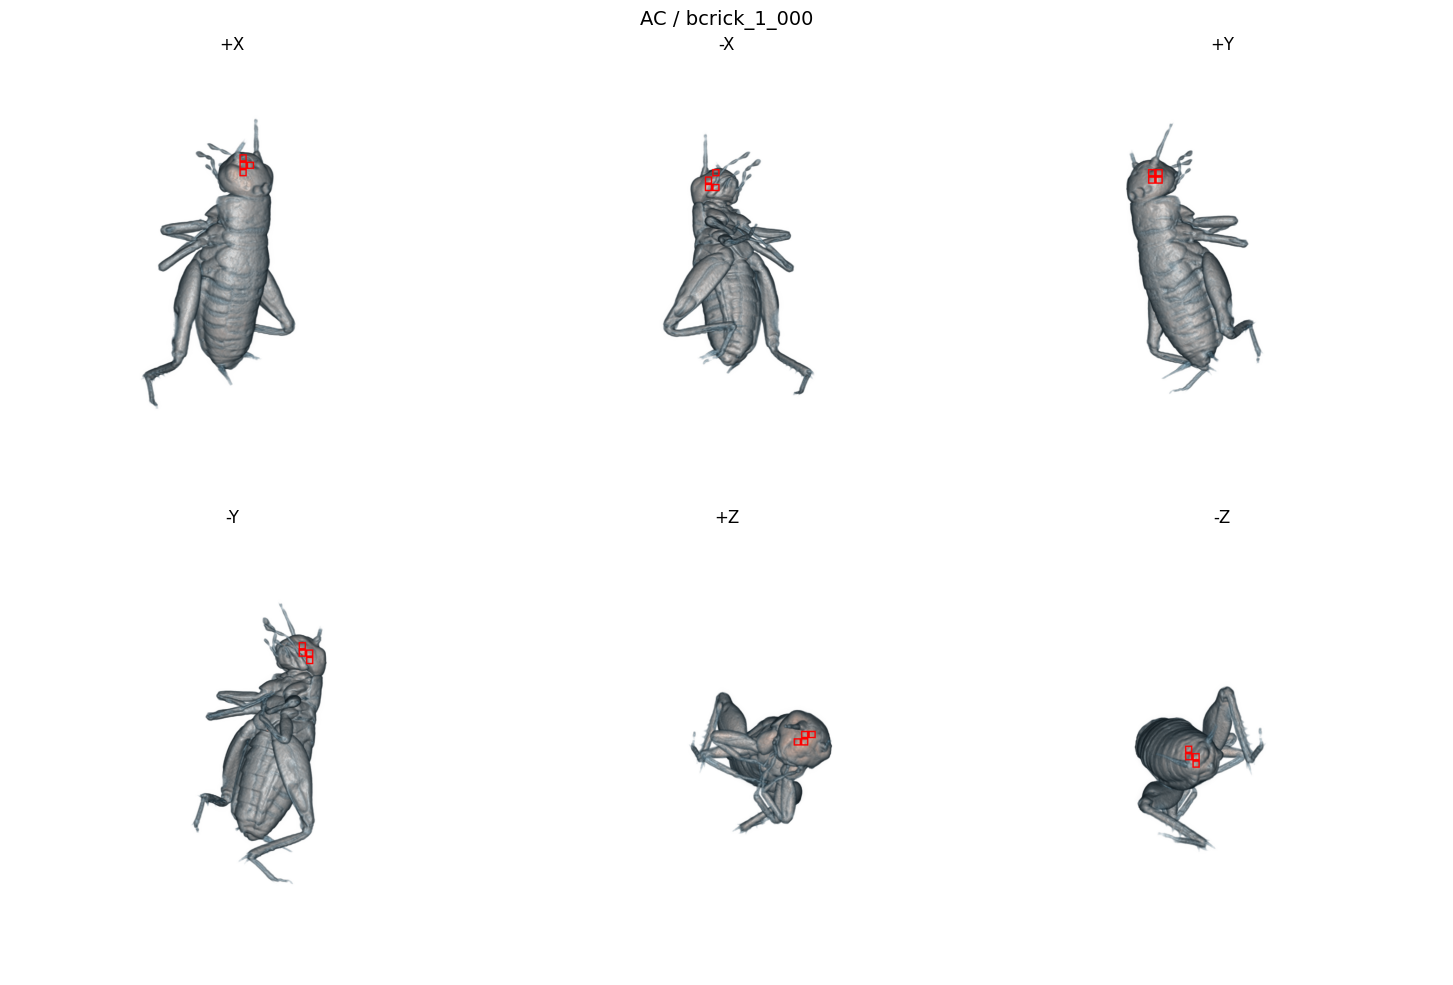

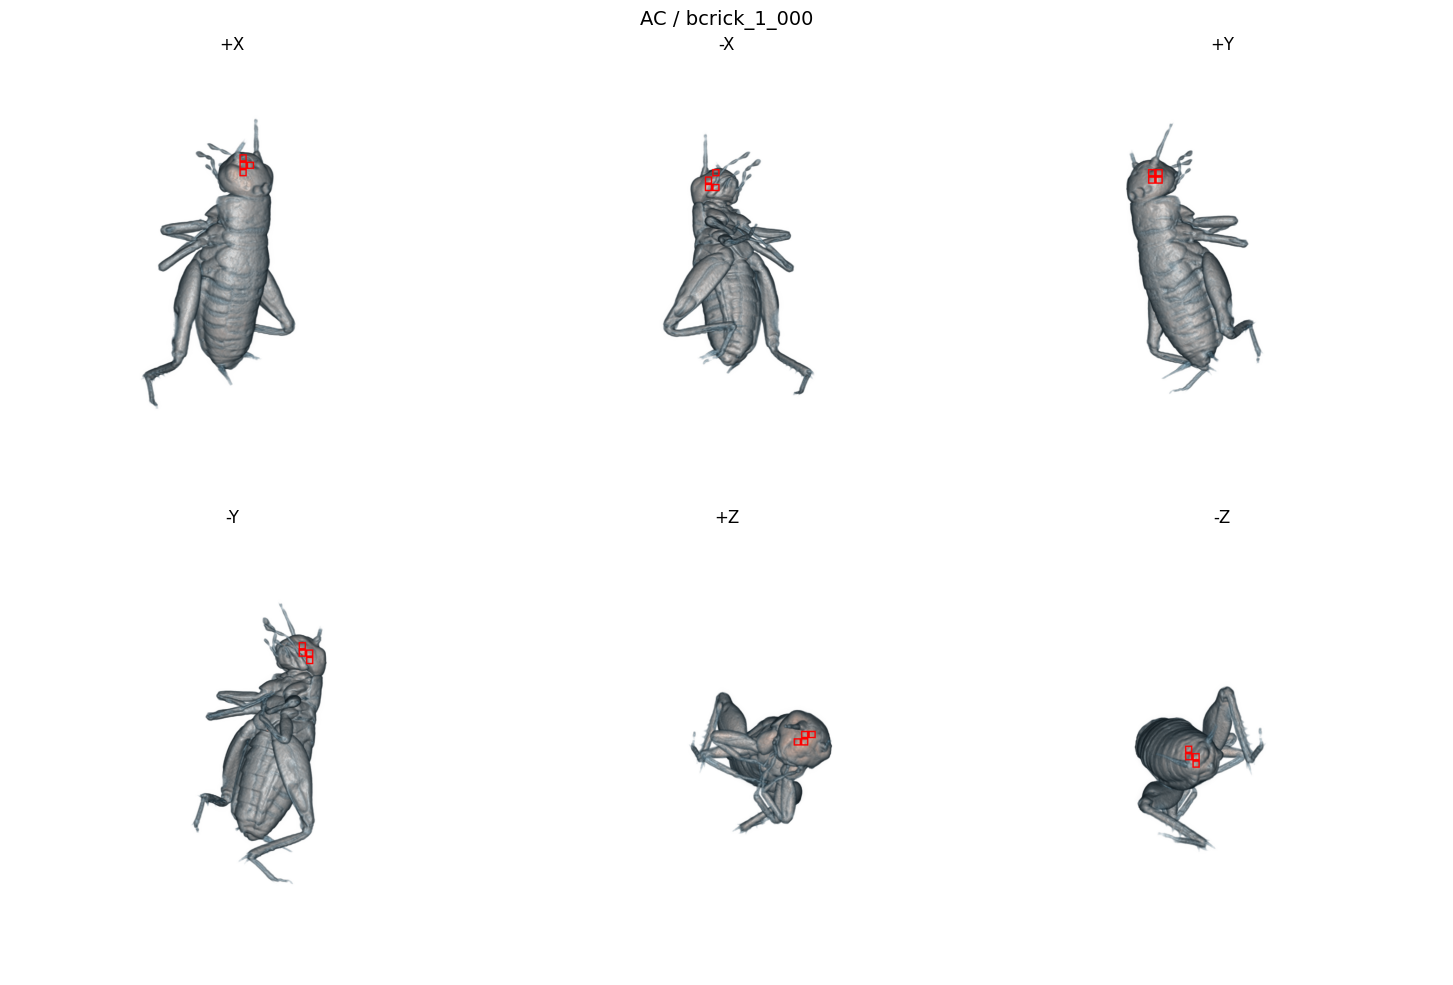

In [94]:
%matplotlib inline
segmented_root = info_path / "segmented"
tokens_root    = info_path / "tokens"
animal         = "AC"
individual     = "bcrick_1_000"

plot_top_k_on_images(segmented_root, tokens_root, animal, individual)